In [1]:
# Import standard libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# Display settings
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
file_path = "datasets/Training_data_uhi_index_UHI2025-v2.csv"
df = pd.read_csv(file_path)
df.head()
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  11229 non-null  float64
 1   Latitude   11229 non-null  float64
 2   datetime   11229 non-null  object 
 3   UHI Index  11229 non-null  float64
dtypes: float64(3), object(1)
memory usage: 351.0+ KB


,Longitude,Latitude,UHI Index
count,11229.000000,11229.000000,11229.000000
mean,-73.933927,40.808800,1.000001
std,0.028253,0.023171,0.016238
min,-73.994457,40.758792,0.956122
25%,-73.955703,40.790905,0.988577
50%,-73.932968,40.810688,1.000237
75%,-73.909647,40.824515,1.011176
max,-73.879458,40.859497,1.046036


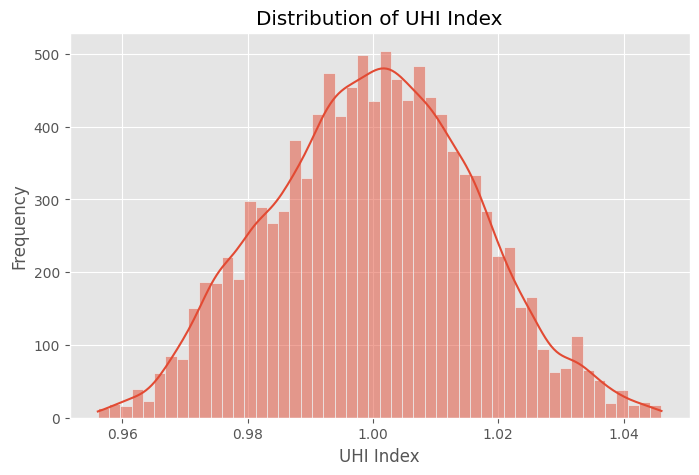

In [3]:
import seaborn as sns

plt.figure(figsize=(8,5))
# print(df.columns)
# Dumbass EY people don't know how to format column headings
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
# print(df.columns)
sns.histplot(df['UHI_Index'], bins=50, kde=True)
plt.title("Distribution of UHI Index")
plt.xlabel("UHI Index")
plt.ylabel("Frequency")
plt.show()

In [4]:
# print(df.columns)
df[['Latitude', 'Longitude']].head()

,Latitude,Longitude
0,40.813107,-73.909167
1,40.813045,-73.909187
2,40.812978,-73.909215
3,40.812908,-73.909242
4,40.812845,-73.909257


In [5]:
import folium
from folium.plugins import HeatMap

map_nyc = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

heat_data = [[row['Latitude'], row['Longitude'], row['UHI_Index']] for index, row in df.iterrows()]
HeatMap(heat_data).add_to(map_nyc)

map_nyc.save("uhi_heatmap.html")

map_nyc


# Extracting NDVI data

NDVI Min: -0.9020461471484545, Max: 0.998703823720026


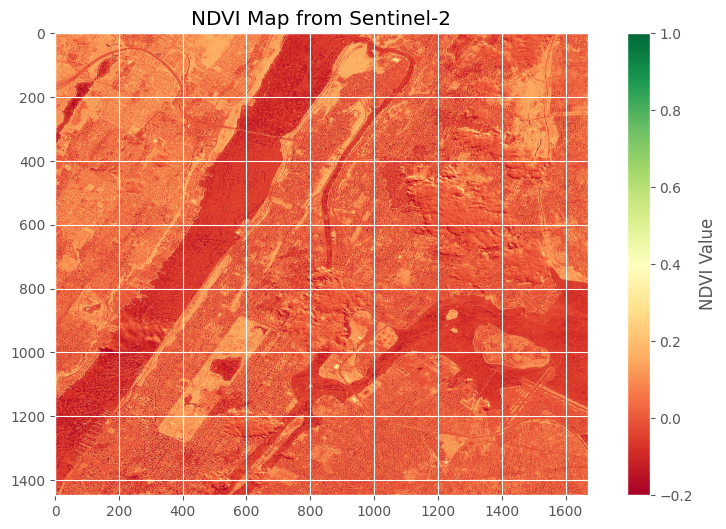

In [7]:
import rasterio
import numpy as np

with rasterio.open("datasets/S2_sample.tiff") as src:
    sentinel_data = src.read()

    red_band = sentinel_data[2]
    nir_band = sentinel_data[3]

    mask = (nir_band + red_band) > 0
    ndvi = np.full_like(nir_band, np.nan)
    ndvi[mask] = (nir_band[mask] - red_band[mask]) / (nir_band[mask] + red_band[mask])
    
    print(f"NDVI Min: {np.nanmin(ndvi)}, Max: {np.nanmax(ndvi)}")

vmin, vmax = -0.2, 1

plt.figure(figsize=(10, 6))
plt.imshow(ndvi, cmap="RdYlGn", vmin=vmin, vmax=vmax)
plt.colorbar(label="NDVI Value")
plt.title("NDVI Map from Sentinel-2")
plt.show()

In [8]:
import pandas as pd
import numpy as np

with rasterio.open("datasets/S2_sample.tiff") as src:
    transform = src.transform
    height, width = ndvi.shape
    
    
    ndvi_list = []
    for row in range(height):
        for col in range(width):
            lon, lat =  transform * (col, row)
            ndvi_value = ndvi[row, col]
            if not np.isnan(ndvi_value):
                ndvi_list.append([lat, lon, ndvi_value])

ndvi_df = pd.DataFrame(ndvi_list, columns=["Latitude", "Longitude", "NDVI"])
ndvi_df = ndvi_df.sample(frac=0.5, random_state=42)
ndvi_df.to_csv("extracted_ndvi_small.csv", index=False)

print("NDVI data saved successfully as extracted_ndvi.csv")
    

NDVI data saved successfully as extracted_ndvi.csv


In [9]:
import pandas as pd

uhi_df = pd.read_csv("datasets/Training_data_uhi_index_UHI2025-v2.csv")

ndvi_df = pd.read_csv("extracted_ndvi_small.csv")

print("UHI Dataset Columns:", uhi_df.columns)
print("NDVI Dataset Columns:", ndvi_df.columns)

print("UHI Dataset (Latitude, Longitude):")
print(uhi_df[['Latitude', 'Longitude']].head())

print("NDVI Dataset (Latitude, Longitude):")
print(ndvi_df[['Latitude', 'Longitude']].head())


from scipy.spatial import cKDTree
import numpy as np

ndvi_tree = cKDTree(ndvi_df[['Latitude', 'Longitude']].values)

for index, row in uhi_df.iterrows():
    _, nearest_index = ndvi_tree.query([row['Latitude'], row['Longitude']])
    uhi_df.at[index, 'NDVI'] = ndvi_df.iloc[nearest_index]['NDVI']

# Save the updated dataset
uhi_df.to_csv("UHI_with_NDVI_nearest.csv", index=False)
print("Merged dataset saved using nearest neighbor method.")

# print(uhi_df.head())


UHI Dataset Columns: Index(['Longitude', 'Latitude', 'datetime', 'UHI Index'], dtype='object')
NDVI Dataset Columns: Index(['Latitude', 'Longitude', 'NDVI'], dtype='object')
UHI Dataset (Latitude, Longitude):
    Latitude  Longitude
0  40.813107 -73.909167
1  40.813045 -73.909187
2  40.812978 -73.909215
3  40.812908 -73.909242
4  40.812845 -73.909257
NDVI Dataset (Latitude, Longitude):
    Latitude  Longitude
0  40.875691 -73.966732
1  40.839599 -73.963770
2  40.871291 -73.972029
3  40.859800 -73.993124
4  40.849116 -73.988097
Merged dataset saved using nearest neighbor method.


# Incorporating LST data

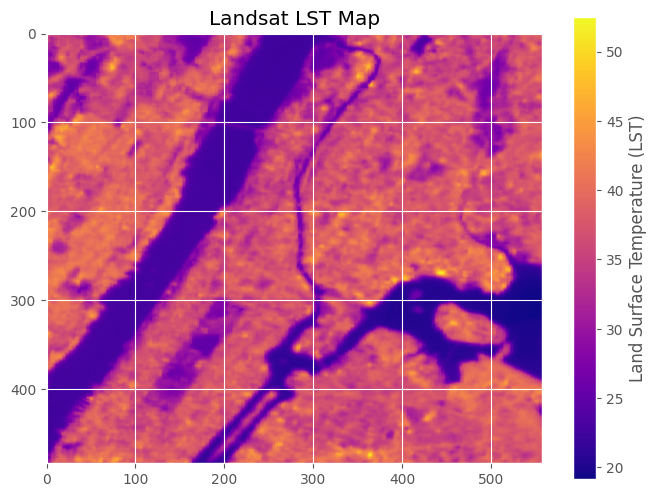

In [10]:
import rasterio
import matplotlib.pyplot as plt

lst_tiff_file = "datasets/Landsat_LST.tiff"

with rasterio.open(lst_tiff_file) as src:
    lst_data = src.read(1)
    transform = src.transform
    
plt.figure(figsize=(8, 6))
plt.imshow(lst_data, cmap="plasma")
plt.colorbar(label="Land Surface Temperature (LST)")
plt.title("Landsat LST Map")
plt.show()

In [11]:
import pandas as pd
import numpy as np

lst_list = []
height, width = lst_data.shape

for row in range(height):
    for col in range(width):
        lon, lat =  transform * (col, row)
        lst_value = lst_data[row, col]
        if not np.isnan(lst_value):
            lst_list.append([lat, lon, lst_value])
            
lst_df = pd.DataFrame(lst_list, columns=["Latitude", "Longitude", "LST"])
lst_df.to_csv("extracted_lst.csv", index=False)

print("LST data saved successfully as extracted_lst.csv")

LST data saved successfully as extracted_lst.csv


In [12]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# Load the existing UHI + NDVI dataset
merged_df = pd.read_csv("UHI_with_NDVI_nearest.csv")

# Load the LST dataset
lst_df = pd.read_csv("extracted_lst.csv")

# Step 1: Merge UHI + NDVI with LST data to create the LST column
merged_df = merged_df.merge(lst_df, on=["Latitude", "Longitude"], how="left")

# Check if 'LST' column exists and the initial count of missing values
print("Columns after merging:", merged_df.columns)
print("Missing LST values after merging:", merged_df['LST'].isnull().sum())

# Step 2: Apply Nearest Neighbor Method for Remaining NaN Values
# Build a KD-Tree for the LST coordinates
lst_tree = cKDTree(lst_df[['Latitude', 'Longitude']].values)

# Fill missing LST values using the nearest neighbor method
for index, row in merged_df.iterrows():
    if pd.isna(row['LST']):  # Only fill missing LST values
        _, nearest_index = lst_tree.query([row['Latitude'], row['Longitude']])
        merged_df.at[index, 'LST'] = lst_df.iloc[nearest_index]['LST']

# Verify if missing LST values have been filled
print("Missing LST values after nearest neighbor fill:", merged_df['LST'].isnull().sum())

# Save the final dataset with nearest neighbor LST values
merged_df.to_csv("UHI_with_NDVI_LST_nearest.csv", index=False)
print("Final dataset saved with nearest neighbor method for LST.")



Columns after merging: Index(['Longitude', 'Latitude', 'datetime', 'UHI Index', 'NDVI', 'LST'], dtype='object')
Missing LST values after merging: 11229
Missing LST values after nearest neighbor fill: 0
Final dataset saved with nearest neighbor method for LST.


In [13]:
print(merged_df.head())
# LOOKING GOOOOOD!!!

   Longitude   Latitude          datetime  UHI Index      NDVI        LST
0 -73.909167  40.813107  24-07-2021 15:53   1.030289  0.118545  38.393941
1 -73.909187  40.813045  24-07-2021 15:53   1.030289  0.118545  38.393941
2 -73.909215  40.812978  24-07-2021 15:53   1.023798  0.133506  38.082901
3 -73.909242  40.812908  24-07-2021 15:53   1.023798  0.133506  38.082901
4 -73.909257  40.812845  24-07-2021 15:53   1.021634  0.133506  38.082901


# Extracting building footprint data - NOT WORKING!!!

In [ ]:
import geopandas as gpd

building_gdf = gpd.read_file("datasets/Building_Footprint.kml", driver='KML')

print(building_gdf.head())
print("Building Footprint Columns:", building_gdf.columns)

building_gdf = building_gdf.to_crs(epsg=3857)

building_gdf['Longitude'] = building_gdf.geometry.centroid.x
building_gdf['Latitude'] = building_gdf.geometry.centroid.y

building_gdf = building_gdf.to_crs(epsg=4326)

building_df = building_gdf[['Latitude', 'Longitude']]

building_df.to_csv("building_footprints_extracted.csv", index=False)
print("✅ Extracted building locations saved correctly.")

  Name Description                                           geometry
0                   MULTIPOLYGON (((-73.91903 40.8482, -73.91933 4...
1                   MULTIPOLYGON (((-73.92195 40.84963, -73.92191 ...
2                   MULTIPOLYGON (((-73.9205 40.85011, -73.92045 4...
3                   MULTIPOLYGON (((-73.92056 40.8514, -73.92053 4...
4                   MULTIPOLYGON (((-73.91234 40.85218, -73.91247 ...
Building Footprint Columns: Index(['Name', 'Description', 'geometry'], dtype='object')
✅ Extracted building locations saved correctly.


In [ ]:
import pandas as pd
from scipy.spatial import cKDTree

# Load extracted building footprints (centroids)
building_df = pd.read_csv("building_footprints_extracted.csv")

# Load the main dataset (UHI + NDVI + LST)
merged_df = pd.read_csv("UHI_with_NDVI_LST_nearest.csv")

# Check the structure of the data
print("Building Data Sample:")
print(building_df.head())

print("\nUHI Data Sample:")
print(merged_df.head())


Building Data Sample:
       Latitude     Longitude
0  4.989962e+06 -8.228656e+06
1  4.990186e+06 -8.228944e+06
2  4.990255e+06 -8.228779e+06
3  4.990447e+06 -8.228789e+06
4  4.990564e+06 -8.227898e+06

UHI Data Sample:
   Longitude   Latitude          datetime  UHI Index      NDVI        LST
0 -73.909167  40.813107  24-07-2021 15:53   1.030289  0.118545  38.393941
1 -73.909187  40.813045  24-07-2021 15:53   1.030289  0.118545  38.393941
2 -73.909215  40.812978  24-07-2021 15:53   1.023798  0.133506  38.082901
3 -73.909242  40.812908  24-07-2021 15:53   1.023798  0.133506  38.082901
4 -73.909257  40.812845  24-07-2021 15:53   1.021634  0.133506  38.082901


In [ ]:
import geopandas as gpd

# Load the building footprint KML file
building_gdf = gpd.read_file("datasets/Building_Footprint.kml", driver="KML")

# Check current CRS
print("Original Building Data CRS:", building_gdf.crs)

# 🚨 Convert to a projected CRS (EPSG:3857) for accurate centroid calculations
projected_gdf = building_gdf.to_crs(epsg=3857)

# Compute centroid in projected CRS (meters)
projected_gdf['centroid'] = projected_gdf.geometry.centroid

# Convert back to EPSG:4326 (Lat/Lon)
building_gdf = projected_gdf.to_crs(epsg=4326)

# Extract latitude & longitude from corrected centroids
building_gdf['Longitude'] = building_gdf['centroid'].x
building_gdf['Latitude'] = building_gdf['centroid'].y

# Keep only relevant columns
building_df = building_gdf[['Latitude', 'Longitude']]

# Save as CSV
building_df.to_csv("building_footprints_extracted.csv", index=False)
print("✅ Building dataset correctly projected and saved.")


# Print the new coordinate range
print("\nCorrected Building Dataset Coordinate Range:")
print("Latitude:", building_df['Latitude'].min(), "to", building_df['Latitude'].max())
print("Longitude:", building_df['Longitude'].min(), "to", building_df['Longitude'].max())


Original Building Data CRS: EPSG:4326
✅ Building dataset correctly projected and saved.

Corrected Building Dataset Coordinate Range:
Latitude: 4975731.964986865 to 4993077.289947035
Longitude: -8237804.812237369 to -8223090.579206002


In [ ]:
# Save the dataset with building features
merged_df.to_csv("UHI_with_NDVI_LST_Building.csv", index=False)
print("✅ Final dataset saved with Building Density and Nearest Building Distance.")


✅ Final dataset saved with Building Density and Nearest Building Distance.


In [14]:
print(merged_df.head())

   Longitude   Latitude          datetime  UHI Index      NDVI        LST
0 -73.909167  40.813107  24-07-2021 15:53   1.030289  0.118545  38.393941
1 -73.909187  40.813045  24-07-2021 15:53   1.030289  0.118545  38.393941
2 -73.909215  40.812978  24-07-2021 15:53   1.023798  0.133506  38.082901
3 -73.909242  40.812908  24-07-2021 15:53   1.023798  0.133506  38.082901
4 -73.909257  40.812845  24-07-2021 15:53   1.021634  0.133506  38.082901


# Incorporating Weather Data - .....yeah we're screwed

In [15]:
import pandas as pd

file_path = "datasets/NY_Mesonet_Weather.xlsx"
xls = pd.ExcelFile(file_path)
print("Available Sheets:", xls.sheet_names)
weather_df = pd.read_excel(xls, sheet_name="Manhattan")

print(weather_df.head())


Available Sheets: ['Summary', 'Terms', 'Location', 'Bronx', 'Manhattan']
               Date / Time  Air Temp at Surface [degC]  \
0  2021-07-24 06:00:00 EDT                        21.3   
1  2021-07-24 06:05:00 EDT                        21.4   
2  2021-07-24 06:10:00 EDT                        21.4   
3  2021-07-24 06:15:00 EDT                        21.5   
4  2021-07-24 06:20:00 EDT                        21.5   

   Relative Humidity [percent]  Avg Wind Speed [m/s]  \
0                         66.5                   0.9   
1                         66.1                   1.1   
2                         66.5                   1.3   
3                         65.4                   1.3   
4                         65.0                   1.5   

   Wind Direction [degrees]  Solar Flux [W/m^2]  
0                       348                  10  
1                       345                  12  
2                         4                  14  
3                         5              

In [16]:
print(weather_df.isnull().sum())


Date / Time                    0
Air Temp at Surface [degC]     0
Relative Humidity [percent]    0
Avg Wind Speed [m/s]           0
Wind Direction [degrees]       0
Solar Flux [W/m^2]             0
dtype: int64


In [17]:
weather_df['Date / Time'] = pd.to_datetime(weather_df['Date / Time'].str.replace(" EDT", "", regex=False))

main_df = pd.read_csv("UHI_with_NDVI_LST_nearest.csv")
main_df['datetime'] = pd.to_datetime(main_df['datetime'])

print("Weather Data Time Range:", weather_df['Date / Time'].min(), "to", weather_df['Date / Time'].max())
print("Main Data Time Range:", main_df['datetime'].min(), "to", main_df['datetime'].max())


Weather Data Time Range: 2021-07-24 06:00:00 to 2021-07-24 20:00:00
Main Data Time Range: 2021-07-24 15:01:00 to 2021-07-24 15:59:00


/var/folders/kr/8m9806_91hvfsn3y7fxqh15c0000gn/T/ipykernel_18342/2078167314.py:4: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  main_df['datetime'] = pd.to_datetime(main_df['datetime'])


In [18]:
from scipy.spatial import cKDTree
import numpy as np

weather_df['timestamp'] = weather_df['Date / Time'].astype(int) // 10**9
main_df['timestamp'] = main_df['datetime'].astype(int) // 10**9

weather_tree = cKDTree(weather_df[['timestamp']].values)

_, nearest_weather_idx = weather_tree.query(main_df[['timestamp']].values)

weather_features = ['Air Temp at Surface [degC]', 'Relative Humidity [percent]', 
                    'Avg Wind Speed [m/s]', 'Wind Direction [degrees]', 'Solar Flux [W/m^2]']
main_df[weather_features] = weather_df.iloc[nearest_weather_idx][weather_features].values

main_df.to_csv("UHI_with_Weather.csv", index=False)

print("Weather features successfully merged! Data saved as 'UHI_with_Weather.csv'.")


Weather features successfully merged! Data saved as 'UHI_with_Weather.csv'.


In [19]:
print(main_df.head())

   Longitude   Latitude            datetime  UHI Index      NDVI        LST  \
0 -73.909167  40.813107 2021-07-24 15:53:00   1.030289  0.118545  38.393941   
1 -73.909187  40.813045 2021-07-24 15:53:00   1.030289  0.118545  38.393941   
2 -73.909215  40.812978 2021-07-24 15:53:00   1.023798  0.133506  38.082901   
3 -73.909242  40.812908 2021-07-24 15:53:00   1.023798  0.133506  38.082901   
4 -73.909257  40.812845 2021-07-24 15:53:00   1.021634  0.133506  38.082901   

    timestamp  Air Temp at Surface [degC]  Relative Humidity [percent]  \
0  1627141980                        26.8                         46.7   
1  1627141980                        26.8                         46.7   
2  1627141980                        26.8                         46.7   
3  1627141980                        26.8                         46.7   
4  1627141980                        26.8                         46.7   

   Avg Wind Speed [m/s]  Wind Direction [degrees]  Solar Flux [W/m^2]  
0       

# First Model

In [20]:
X_new = main_df.drop(columns=['Latitude', 'Longitude', 'timestamp', 'datetime', 'UHI Index'])
y = main_df['UHI Index']

print("Final Features Used in Model:", X_new.columns)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

rf_model_new = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model_new.fit(X_train_new, y_train_new)

y_pred_new = rf_model_new.predict(X_test_new)

mse_new = mean_squared_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print(f"Updated Model Performance with Weather Data: MSE: {mse_new:.4f}, R²: {r2_new:.4f}")



Final Features Used in Model: Index(['NDVI', 'LST', 'Air Temp at Surface [degC]',
       'Relative Humidity [percent]', 'Avg Wind Speed [m/s]',
       'Wind Direction [degrees]', 'Solar Flux [W/m^2]'],
      dtype='object')
Updated Model Performance with Weather Data: MSE: 0.0001, R²: 0.6283


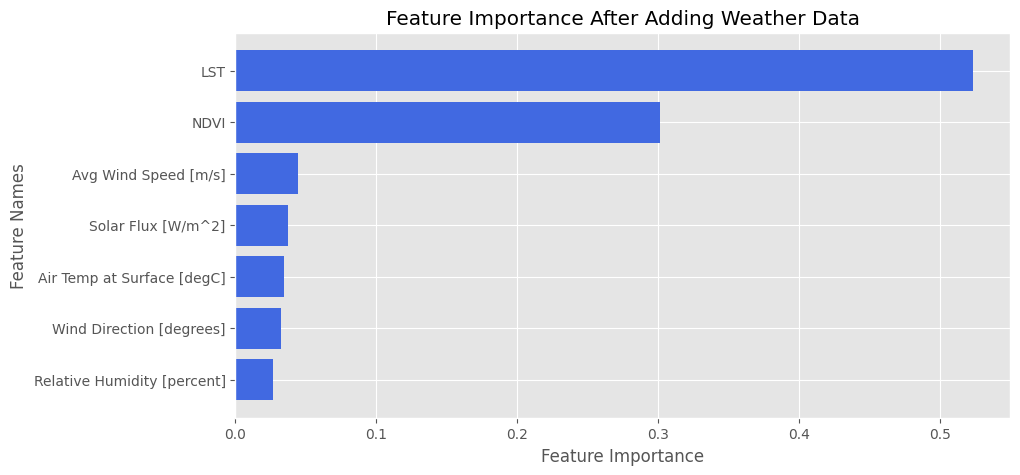

In [21]:
import matplotlib.pyplot as plt
import numpy as np

feature_importance_new = rf_model_new.feature_importances_

feature_names_new = X_new.columns

sorted_idx = np.argsort(feature_importance_new)

plt.figure(figsize=(10, 5))
plt.barh(np.array(feature_names_new)[sorted_idx], feature_importance_new[sorted_idx], color='royalblue')
plt.xlabel("Feature Importance")
plt.ylabel("Feature Names")
plt.title("Feature Importance After Adding Weather Data")
plt.show()


In [24]:
X_new = X_new.rename(columns={'Date / Time': 'datetime'})


In [27]:
# X_new = X_new.drop(columns=['datetime'])  # Use the correct column name


In [28]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Ensure correct column names
print("Columns in dataset:", main_df.columns)

# Drop unused or problematic columns
X_new = main_df.drop(columns=['Latitude', 'Longitude', 'timestamp', 'datetime', 'UHI Index'], errors='ignore')
y = main_df['UHI Index']

# Convert datetime to numerical features if still present
if 'Date / Time' in X_new.columns:
    X_new['Date / Time'] = pd.to_datetime(X_new['Date / Time'])
    X_new['hour'] = X_new['Date / Time'].dt.hour
    X_new['day'] = X_new['Date / Time'].dt.day
    X_new['month'] = X_new['Date / Time'].dt.month
    X_new = X_new.drop(columns=['Date / Time'])

# Print final feature set
print("✅ Final Features Used in Model:", X_new.columns)

# Split the data
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Train Random Forest Model
rf_model_new = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model_new.fit(X_train_new, y_train_new)

# Make predictions
y_pred_new = rf_model_new.predict(X_test_new)

# Evaluate performance
mse_new = mean_squared_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print(f"🌤️ Updated Model Performance: MSE: {mse_new:.4f}, R²: {r2_new:.4f}")


Columns in dataset: Index(['Longitude', 'Latitude', 'datetime', 'UHI Index', 'NDVI', 'LST',
       'timestamp', 'Air Temp at Surface [degC]',
       'Relative Humidity [percent]', 'Avg Wind Speed [m/s]',
       'Wind Direction [degrees]', 'Solar Flux [W/m^2]'],
      dtype='object')
✅ Final Features Used in Model: Index(['NDVI', 'LST', 'Air Temp at Surface [degC]',
       'Relative Humidity [percent]', 'Avg Wind Speed [m/s]',
       'Wind Direction [degrees]', 'Solar Flux [W/m^2]'],
      dtype='object')
🌤️ Updated Model Performance: MSE: 0.0001, R²: 0.6283


In [29]:
import pandas as pd

# Load validation dataset (replace with actual file path)
validation_df = pd.read_csv("Submission_template_UHI2025-v2.csv")

# Preview the validation dataset
print(validation_df.head())

   Longitude   Latitude  UHI Index
0 -73.971665  40.788763        NaN
1 -73.971928  40.788875        NaN
2 -73.967080  40.789080        NaN
3 -73.972550  40.789082        NaN
4 -73.969697  40.787953        NaN


In [32]:
# Drop 'UHI Index' from validation set (it should not be used in prediction)
X_validation = X_validation.drop(columns=['UHI Index'], errors='ignore')

# Fill missing columns with training set median
for col in missing_cols:
    X_validation[col] = X_train_new[col].median()

# Ensure the same column order
X_validation = X_validation[X_train_new.columns]

print("✅ Validation dataset is now correctly formatted for prediction.")



✅ Validation dataset is now correctly formatted for prediction.


In [33]:
# Make predictions using the trained model
validation_df['UHI_Predicted'] = rf_model_new.predict(X_validation)

# Save predictions to CSV for submission
validation_df[['Latitude', 'Longitude', 'UHI_Predicted']].to_csv("trial_submission.csv", index=False)

print("✅ Trial submission saved as trial_submission.csv")


✅ Trial submission saved as trial_submission.csv


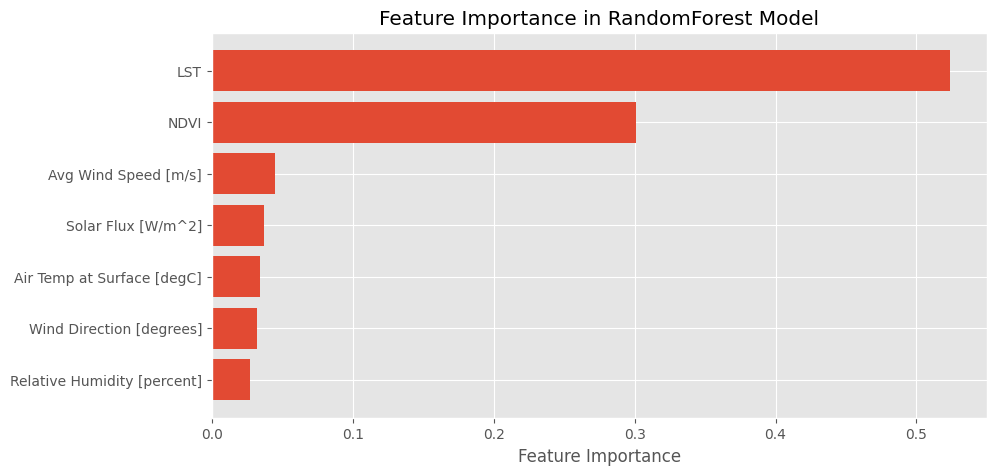

In [34]:
import matplotlib.pyplot as plt
import numpy as np

feature_importances = rf_model_new.feature_importances_
sorted_idx = np.argsort(feature_importances)

plt.figure(figsize=(10, 5))
plt.barh(np.array(X_new.columns)[sorted_idx], feature_importances[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Feature Importance in RandomForest Model")
plt.show()


In [35]:
print("Training data stats:\n", X_new.describe())
print("Validation data stats:\n", X_validation.describe())


Training data stats:
                NDVI           LST  Air Temp at Surface [degC]  \
count  11229.000000  11229.000000                11229.000000   
mean       0.001021     36.927445                   26.842266   
std        0.106449      2.463195                    0.301903   
min       -0.592375     28.259512                   26.100000   
25%       -0.056667     35.758648                   26.600000   
50%        0.004995     37.180544                   26.800000   
75%        0.065392     38.465720                   27.100000   
max        0.403792     46.781762                   27.300000   

       Relative Humidity [percent]  Avg Wind Speed [m/s]  \
count                 11229.000000          11229.000000   
mean                     47.869882              2.937857   
std                       1.734127              0.692522   
min                      45.400000              1.400000   
25%                      46.700000              2.400000   
50%                      47.6000